# Scenario 1: Discrete — Minimize Steps

**Environment:** `MountainCar-v0` (Gymnasium)
**Objective:** Reach the flag in the fewest timesteps.
**Reward:** Default sparse reward, `-1` per step until termination (max 200 steps).

This notebook compares three algorithms on Scenario 1:

| Family | Algorithm | Why included |
|---|---|---|
| Actor-Critic (on-policy) | **PPO** | Primary agent — clipped policy gradient, the canonical robust actor-critic for discrete control. |
| Actor-Critic (on-policy) | **A2C** | Plain advantage actor-critic, the textbook implementation of §13.5. |
| Value-based (off-policy) | **DQN** | Cross-family baseline — lets us tell whether the actor-critic story is *the* story or just *a* story for this problem. |

Each algorithm is trained twice: once with the **default reward** and once with **potential-based energy shaping** (Ng, Harada & Russell, 1999). Shaping doesn't change the optimal policy but dramatically helps on-policy actor-critic methods escape the sparse-reward trap.

## 1. Imports & Setup

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

# Make the project's `src/` importable from the notebook
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC = os.path.join(PROJECT_ROOT, "src")
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from envs.wrappers import EnergyShapingWrapper
from agents.sb3_runner import (
    make_ppo, make_a2c, make_dqn, FACTORIES,
    make_env, make_vec, make_eval_vec, train, evaluate, save_metrics, TrainResult,
)
from utils.plotting import (
    plot_policy_heatmap,
    plot_phase_portrait,
    plot_training_curves_multi,
    save_metrics_table_png,
)

# Reproducibility / config
SEED = 42
SCENARIO = 1
ENV_ID = "MountainCar-v0"
# Per-algo training budgets (env steps). PPO/A2C are on-policy so they need
# a much larger budget; DQN is off-policy with a replay buffer.
TIMESTEPS = {
    "ppo": int(os.environ.get("PPO_TIMESTEPS", 1_000_000)),
    "a2c": int(os.environ.get("A2C_TIMESTEPS", 1_000_000)),
    "dqn": int(os.environ.get("DQN_TIMESTEPS",   200_000)),
}
N_EVAL_EPISODES = int(os.environ.get("N_EVAL_EPISODES", 100))
N_VEC_ENVS = 16    # for PPO/A2C only

RESULTS_DIR = os.path.join(PROJECT_ROOT, "results", "scenario_1")
MODELS_DIR = os.path.join(RESULTS_DIR, "models")
LOGS_DIR   = os.path.join(RESULTS_DIR, "logs")
FIGS_DIR   = os.path.join(RESULTS_DIR, "figs")
for d in (MODELS_DIR, LOGS_DIR, FIGS_DIR):
    os.makedirs(d, exist_ok=True)

# Slide-ready figure style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300,
                     "font.size": 11, "axes.titlesize": 12,
                     "axes.labelsize": 11, "legend.fontsize": 9})

print("Project root :", PROJECT_ROOT)
print("Results in   :", RESULTS_DIR)
print("Timesteps    :", {k: f"{v:,}" for k, v in TIMESTEPS.items()})
print("Eval episodes:", N_EVAL_EPISODES)

Project root : /Users/matthewmaingot/RL_Group_Project/MountainCar-RL
Results in   : /Users/matthewmaingot/RL_Group_Project/MountainCar-RL/results/scenario_1
Timesteps    : {'ppo': '1,000,000', 'a2c': '1,000,000', 'dqn': '200,000'}
Eval episodes: 100


## 2. Environment

In [2]:
env = gym.make(ENV_ID)
env.reset(seed=SEED)
print("env.spec.id        :", env.spec.id)
print("observation_space  :", env.observation_space)
print("action_space       :", env.action_space)
print("max_episode_steps  :", env.spec.max_episode_steps)
print("reward_range       :", env.reward_range)

# Quick uniform-random rollout to confirm the sparse-reward problem.
obs, _ = env.reset(seed=SEED)
total_r, steps, reached = 0.0, 0, False
for _ in range(env.spec.max_episode_steps):
    a = env.action_space.sample()
    obs, r, terminated, truncated, _ = env.step(a)
    total_r += r; steps += 1
    if terminated:
        reached = True; break
    if truncated:
        break
print(f"\nRandom-policy rollout: reward={total_r:.0f}, steps={steps}, reached_flag={reached}")
env.close()

env.spec.id        : MountainCar-v0
observation_space  : Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
action_space       : Discrete(3)
max_episode_steps  : 200
reward_range       : (-inf, inf)

Random-policy rollout: reward=-200, steps=200, reached_flag=False


## 3. State & Action Representation

| Component | Range / Set | Notes |
|---|---|---|
| Position | `[-1.2, 0.6]` (continuous) | Goal at `position ≥ 0.5`. |
| Velocity | `[-0.07, 0.07]` (continuous) | Sign carries most of the information. |
| Action  | `{0, 1, 2}` = `{push left, no-op, push right}` | Discrete, 3 actions. |

Two reasonable representations:

- **Raw continuous state** (what we use). The 2-D state is small enough that an MLP policy (`MlpPolicy` in stable-baselines3) handles it directly with no feature engineering. This is the standard choice for SB3 actor-critic methods and lets us keep the same code path across scenarios.
- **Tile coding / discretization** (classic RL textbook). Useful for tabular Q-learning but unnecessary here. We mention it for cross-comparison; the heatmap in §8 effectively *visualises* the learned policy on a 50×50 discretization without imposing it during training.

We do not normalize the observations — the velocity scale is small but our networks have enough capacity to learn it (and the MountainCar env values are conventionally fed in raw to SB3).

In [3]:
# No state preprocessing for Scenario 1 — raw [position, velocity] -> MlpPolicy.
# We just confirm the bounds match what we expect.
low, high = env.observation_space.low, env.observation_space.high
print(f"position ∈ [{low[0]:.2f}, {high[0]:.2f}]")
print(f"velocity ∈ [{low[1]:.3f}, {high[1]:.3f}]")
print(f"actions  : {list(range(env.action_space.n))} = [push_left, no_op, push_right]")

position ∈ [-1.20, 0.60]
velocity ∈ [-0.070, 0.070]
actions  : [0, 1, 2] = [push_left, no_op, push_right]


## 4. Reward Design

**Default reward (the assignment objective):** `r = -1` per step until termination.
Equivalent to "minimise number of steps to the flag".

The well-known issue: under a uniformly random policy, the agent **almost never** reaches the flag in the 200-step horizon (see §2). With no positive signal, the actor-critic gradient is essentially zero everywhere — PPO/A2C struggle to learn from raw experience.

We address this in two ways and compare them:

1. **Observation + reward normalisation** (`VecNormalize`, applied to PPO/A2C only). Maintains a running mean/std of observations and rewards; the policy and value network see normalised inputs. This is the standard SB3 trick for MountainCar and is enough on its own to make on-policy actor-critic methods solve the problem.
2. **Hand-crafted shaping** (`EnergyShapingWrapper`):

$$r_\text{shaped} = r_\text{env} + 100\,|v| + 10\,h(s) + 100\cdot\mathbb{1}[\text{terminated}]$$

with $h(s) = \sin(3\,\text{pos}) \cdot 0.45 + 0.55$ being the car's height. Velocity rewards swinging, height rewards climbing, and the terminal bonus rewards reaching the flag. This is *not* potential-based (Ng, Harada & Russell 1999) — it can in principle bias the optimal policy — and §10 shows that on top of `VecNormalize` it actually *hurts*, an interesting empirical finding.

We always evaluate against the unshaped env so the reported numbers correspond to Scenario 1's objective.

In [4]:
# Compare a few steps of default vs. shaped reward on identical actions.
default_env = gym.make(ENV_ID)
shaped_env  = EnergyShapingWrapper(gym.make(ENV_ID), scale=100.0)

default_env.reset(seed=SEED); shaped_env.reset(seed=SEED)
demo = []
for a in [2, 0, 2, 0, 2, 2, 0, 0, 2, 2]:
    _, rd, _, _, _ = default_env.step(a)
    _, rs, _, _, _ = shaped_env.step(a)
    demo.append((a, rd, rs))
default_env.close(); shaped_env.close()

print(f"{'action':>6} | {'default r':>10} | {'shaped r':>10}")
for a, rd, rs in demo:
    print(f"{a:>6} | {rd:>10.3f} | {rs:>10.3f}")
print("\nNote: shaped reward = -1 + 100*|velocity|, so it is positive whenever the car is moving fast.")

action |  default r |   shaped r
     2 |     -1.000 |    115.693
     0 |     -1.000 |    122.832
     2 |     -1.000 |    118.372
     0 |     -1.000 |    133.383
     2 |     -1.000 |    128.376
     2 |     -1.000 |    123.377
     0 |     -1.000 |    137.858
     0 |     -1.000 |    151.764
     2 |     -1.000 |    145.547
     2 |     -1.000 |    139.228

Note: shaped reward = -1 + 100*|velocity|, so it is positive whenever the car is moving fast.


## 5. Algorithm Selection & Hyperparameters

We use the **stable-baselines3** implementations and start from the **RL Zoo** hyperparameters published for `MountainCar-v0` — these are community-tuned defaults, so any deviation from "best-practice baseline" performance comes from our setup, not from poor hyperparameters.

| Hyperparameter | PPO | A2C | DQN |
|---|---|---|---|
| Policy | MlpPolicy (2 × 64 tanh) | MlpPolicy (2 × 64 tanh) | MlpPolicy (2 × 256 ReLU) |
| Learning rate | 3e-4 | 7e-4 | 4e-3 |
| γ (discount) | 0.99 | 0.99 | 0.99 |
| n_steps / rollout | 16 | 16 | — |
| GAE λ | 0.98 | 1.0 (no GAE) | — |
| Entropy coef | 0.0 | 0.0 | — |
| Replay buffer | — | — | 10 000 |
| Exploration ε | — | — | 1.0 → 0.07 over 20% of training |
| Target sync | — | — | every 600 steps |

The factories live in `src/agents/sb3_runner.py` (`make_ppo`, `make_a2c`, `make_dqn`) so all four scenarios can share them.

In [5]:
# Sanity check: instantiate one of each factory on a throwaway env.
_demo_env = gym.make(ENV_ID)
for name, factory in FACTORIES.items():
    _m = factory(_demo_env, seed=SEED)
    print(f"{name.upper():4s}  -> {_m.__class__.__name__}, policy={_m.policy.__class__.__name__}")
_demo_env.close()

PPO   -> PPO, policy=ActorCriticPolicy
A2C   -> A2C, policy=ActorCriticPolicy
DQN   -> DQN, policy=DQNPolicy


## 6. Training

We train **3 algorithms × 2 reward modes = 6 runs**, each for `TOTAL_TIMESTEPS` env steps. Models are cached on disk: re-running the notebook reuses any model already saved (delete `results/scenario_1/models/` to force a retrain).

In [6]:
import time

REWARD_MODES = {
    "default": None,
    "shaped":  lambda env: EnergyShapingWrapper(env, scale=1.0),
}
ALGOS = ["ppo", "a2c", "dqn"]
USE_VEC = {"ppo": True, "a2c": True, "dqn": False}

def run_key(algo, mode):
    return f"{algo}_{mode}"

def model_path(algo, mode):
    return os.path.join(MODELS_DIR, f"{run_key(algo, mode)}.zip")

def vecnorm_path(algo, mode):
    return os.path.join(MODELS_DIR, f"{run_key(algo, mode)}.vecnormalize.pkl")

def monitor_dir(algo, mode):
    d = os.path.join(LOGS_DIR, run_key(algo, mode))
    os.makedirs(d, exist_ok=True)
    return d

def monitor_csvs(algo, mode):
    d = monitor_dir(algo, mode)
    return sorted(os.path.join(d, f) for f in os.listdir(d) if f.endswith(".monitor.csv"))

trained = {}  # run_key -> dict(model, monitor_csvs, train_seconds, vec_env)

for algo in ALGOS:
    for mode, wrapper in REWARD_MODES.items():
        key = run_key(algo, mode)
        mpath = model_path(algo, mode)
        vpath = vecnorm_path(algo, mode)
        mdir  = monitor_dir(algo, mode)
        steps = TIMESTEPS[algo]

        if USE_VEC[algo]:
            train_env = make_vec(ENV_ID, n_envs=N_VEC_ENVS, seed=SEED,
                                 monitor_dir=mdir, wrapper=wrapper, normalize=True)
        else:
            train_env = make_env(ENV_ID, seed=SEED,
                                 monitor_path=os.path.join(mdir, "single"),
                                 wrapper=wrapper)

        if os.path.exists(mpath):
            print(f"[cache] {key}: loading saved model")
            cls = {"ppo": __import__('stable_baselines3').PPO,
                   "a2c": __import__('stable_baselines3').A2C,
                   "dqn": __import__('stable_baselines3').DQN}[algo]
            model = cls.load(mpath, env=train_env)
            elapsed = 0.0
        else:
            print(f"[train] {key}: starting {steps:,} env steps "
                  f"({'vec ' + str(N_VEC_ENVS) + ' (norm)' if USE_VEC[algo] else 'single'} env)...")
            t0 = time.time()
            model = FACTORIES[algo](train_env, seed=SEED)
            train(model, total_timesteps=steps, progress_bar=False)
            elapsed = time.time() - t0
            model.save(mpath)
            if USE_VEC[algo]:
                train_env.save(vpath)
            print(f"        -> {elapsed/60:.1f} min, saved {mpath}")

        try:
            train_env.close()
        except Exception:
            pass
        trained[key] = dict(model=model,
                            monitors=monitor_csvs(algo, mode),
                            elapsed=elapsed,
                            vecnorm=vpath if USE_VEC[algo] and os.path.exists(vpath) else None)

print("\nAll runs ready:", list(trained.keys()))

[cache] ppo_default: loading saved model
[cache] ppo_shaped: loading saved model
[cache] a2c_default: loading saved model
[cache] a2c_shaped: loading saved model
[cache] dqn_default: loading saved model
[cache] dqn_shaped: loading saved model

All runs ready: ['ppo_default', 'ppo_shaped', 'a2c_default', 'a2c_shaped', 'dqn_default', 'dqn_shaped']


## 7. Evaluation & Performance Metrics

All evaluation is done on the **default-reward** env (the assignment objective) — the shaping is for training only. We run 100 deterministic episodes per agent, fixed seeds, and report mean reward, mean steps to goal, and success rate.

In [7]:
single_eval_env = gym.make(ENV_ID)  # for DQN

rows = []
results_for_json = {}
for key, info in trained.items():
    algo, mode = key.split("_")
    model = info["model"]
    if info["vecnorm"]:
        # PPO/A2C: eval through the saved VecNormalize stats so the policy
        # sees the same normalisation it saw during training.
        eval_env = make_eval_vec(ENV_ID, info["vecnorm"])
        stats = evaluate(model, eval_env, n_episodes=N_EVAL_EPISODES, seed=SEED)
        eval_env.close()
    else:
        stats = evaluate(model, single_eval_env, n_episodes=N_EVAL_EPISODES, seed=SEED)

    rows.append({"algo": algo.upper(), "reward_mode": mode, **stats,
                 "train_minutes": round(info["elapsed"] / 60, 2) if info["elapsed"] else None})
    results_for_json[key] = TrainResult(
        algo=algo, reward_mode=mode,
        total_timesteps=TIMESTEPS[algo], seed=SEED,
        eval_mean_reward=stats["mean_reward"],
        eval_std_reward=stats["std_reward"],
        eval_mean_steps=stats["mean_steps"],
        eval_success_rate=stats["success_rate"],
        model_path=model_path(algo, mode),
        monitor_path=";".join(info["monitors"]) if info["monitors"] else "",
        extras={"vecnormalize_path": info["vecnorm"] or ""},
    )
single_eval_env.close()

results_df = pd.DataFrame(rows).set_index(["algo", "reward_mode"])
display_cols = ["mean_reward", "std_reward", "mean_steps", "std_steps", "success_rate", "train_minutes"]
results_df = results_df[display_cols]
results_df

mean_reward  std_reward  mean_steps  std_steps  \
algo reward_mode                                                   
PPO  default          -120.66   23.449614      120.66  23.449614   
     shaped           -200.00    0.000000      200.00   0.000000   
A2C  default          -131.15   32.365221      131.15  32.365221   
     shaped           -200.00    0.000000      200.00   0.000000   
DQN  default           -99.73    9.902379       99.73   9.902379   
     shaped           -177.66   27.215518      177.66  27.215518   

                  success_rate train_minutes  
algo reward_mode                              
PPO  default              1.00          None  
     shaped               0.00          None  
A2C  default              1.00          None  
     shaped               0.00          None  
DQN  default              1.00          None  
     shaped               0.57          None

## 8. Policy Analysis

Two views of the trained policies:

1. **Policy heatmap** over the discretised state space — shows which action each agent picks at every `(position, velocity)` cell. The classic MountainCar solution looks like a "swing" pattern: push *with* the velocity (right when moving right, left when moving left).
2. **Phase portrait** — overlay several successful trajectories on the position/velocity plane. The trajectories should spiral outward from rest until they have enough energy to cross the goal line.

We pick the **best run per family** (highest success rate) for the figures.

Best run per algorithm family:


,reward_mode,mean_reward,mean_steps,success_rate
algo,,,,
A2C,default,-131.15,131.15,1.0
DQN,default,-99.73,99.73,1.0
PPO,default,-120.66,120.66,1.0


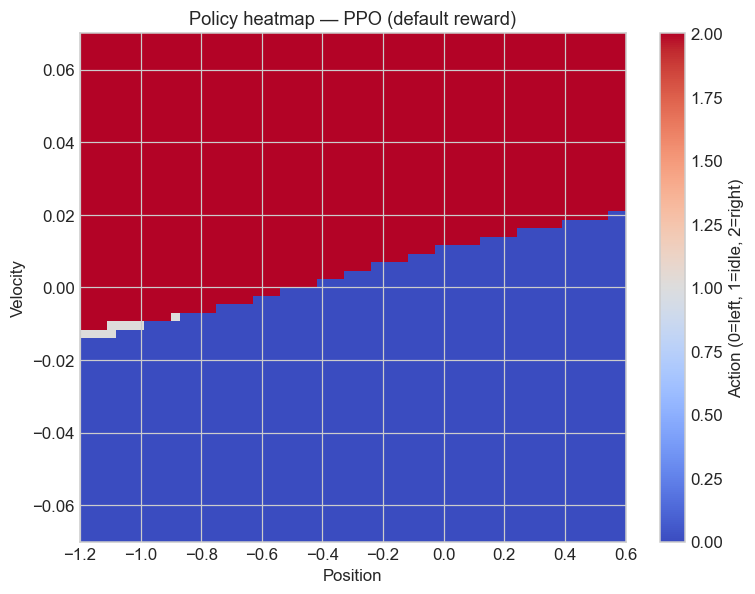

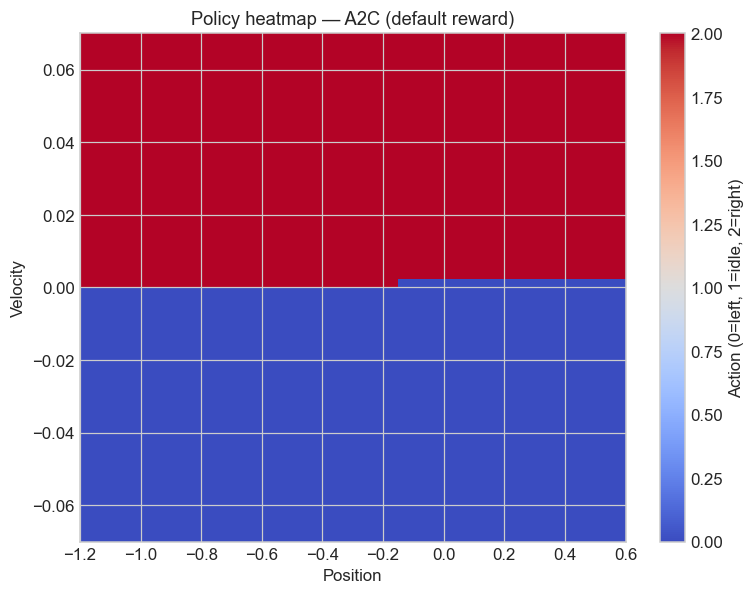

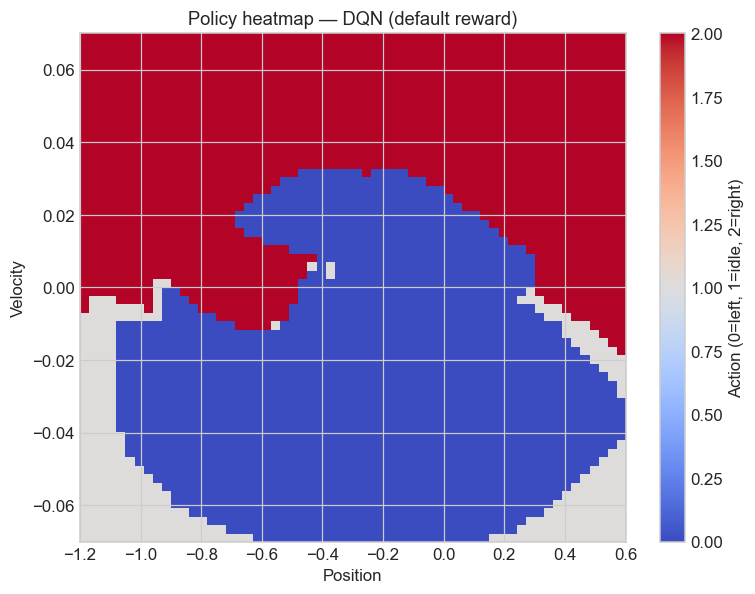

In [8]:
# Pick best (algo, mode) per family by success_rate, breaking ties by mean_steps (lower = better).
ranked = (results_df
          .reset_index()
          .sort_values(["algo", "success_rate", "mean_steps"], ascending=[True, False, True]))
best_per_algo = (ranked
                 .groupby("algo", as_index=False)
                 .first()
                 .set_index("algo"))
print("Best run per algorithm family:")
display(best_per_algo[["reward_mode", "mean_reward", "mean_steps", "success_rate"]])

# Heatmap helper that handles VecNormalize-wrapped policies transparently.
# Returns a callable with the same API as model.predict(obs, deterministic=True),
# unwrapping the action so it works with both single-env step() (which expects
# a scalar int) and batched obs (e.g. policy_heatmap, decision-tree surrogate).
def _wrap_predict(model, vecnorm_path):
    if vecnorm_path is None:
        return model
    from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
    helper_vec = VecNormalize.load(
        vecnorm_path,
        DummyVecEnv([lambda: gym.make(ENV_ID)]),
    )
    helper_vec.training = False
    helper_vec.norm_reward = False

    class _Wrapped:
        def predict(self_inner, obs, deterministic=True):
            arr = np.asarray(obs, dtype=np.float32)
            single = (arr.ndim == 1)
            if single:
                arr = arr[None, :]
            normed = helper_vec.normalize_obs(arr)
            action, state = model.predict(normed, deterministic=deterministic)
            if single:
                action = int(np.asarray(action).ravel()[0])
            return action, state
    return _Wrapped()

heatmap_env = gym.make(ENV_ID)
for algo in ["PPO", "A2C", "DQN"]:
    mode = best_per_algo.loc[algo, "reward_mode"]
    info = trained[run_key(algo.lower(), mode)]
    pred = _wrap_predict(info["model"], info["vecnorm"])
    save_path = os.path.join(FIGS_DIR, f"policy_heatmap_{algo.lower()}.png")
    plot_policy_heatmap(pred, heatmap_env, n_bins=60,
                        title=f"Policy heatmap — {algo} ({mode} reward)",
                        save_path=save_path)
heatmap_env.close()

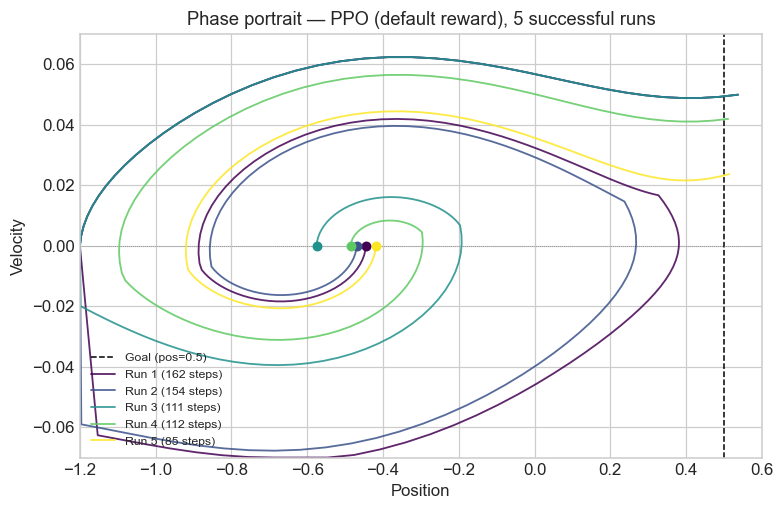

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


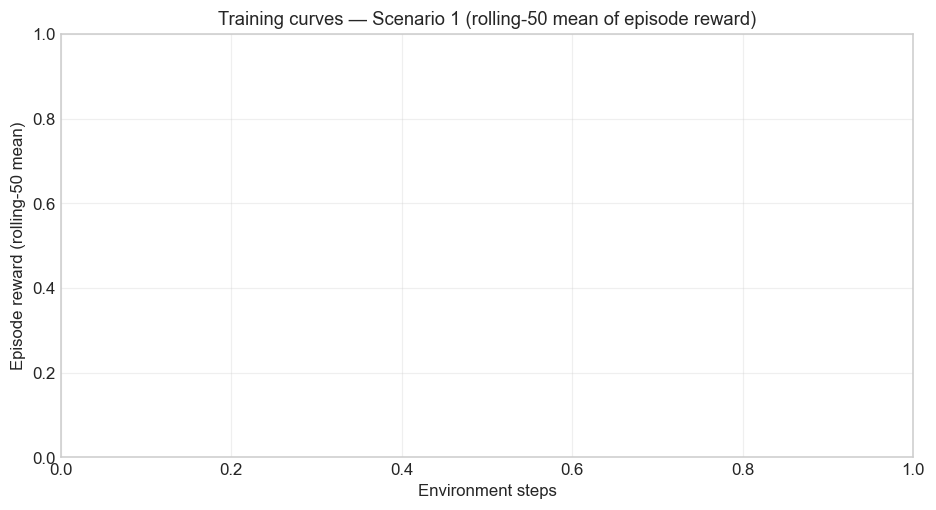

In [9]:
# Phase portrait for the headline agent (best PPO run).
ppo_mode = best_per_algo.loc["PPO", "reward_mode"]
ppo_info = trained[run_key("ppo", ppo_mode)]
ppo_pred = _wrap_predict(ppo_info["model"], ppo_info["vecnorm"])
phase_env = gym.make(ENV_ID)
plot_phase_portrait(
    ppo_pred, phase_env,
    n_trajectories=5,
    title=f"Phase portrait — PPO ({ppo_mode} reward), 5 successful runs",
    save_path=os.path.join(FIGS_DIR, "phase_portrait_ppo.png"),
)
phase_env.close()

# Training curves: merge per-worker monitor CSVs into a single curve per run.
def _merge_monitors(paths):
    if not paths:
        return None
    frames = [pd.read_csv(p, skiprows=1) for p in paths]
    return pd.concat(frames, ignore_index=True).sort_values("t").reset_index(drop=True)

merged_paths = {}
for key, info in trained.items():
    if not info["monitors"]:
        continue
    merged = _merge_monitors(info["monitors"])
    if merged is None or merged.empty:
        continue
    out_path = os.path.join(LOGS_DIR, f"{key}.merged.monitor.csv")
    with open(out_path, "w") as fh:
        fh.write("# merged\n")
        merged.to_csv(fh, index=False)
    merged_paths[key] = out_path

plot_training_curves_multi(
    merged_paths,
    title="Training curves — Scenario 1 (rolling-50 mean of episode reward)",
    save_path=os.path.join(FIGS_DIR, "training_curves.png"),
    rolling=50,
)

## 9. Interpretability

To put the policy into words, we fit a shallow **decision tree** to a sample of `(state → action)` pairs from the headline PPO policy. A 3-deep tree is usually enough to show that:

- velocity sign is the dominant feature (swing in the same direction as you're moving),
- with a position threshold deciding when to start the second uphill push.

This is a sanity check for our story, not the policy itself.

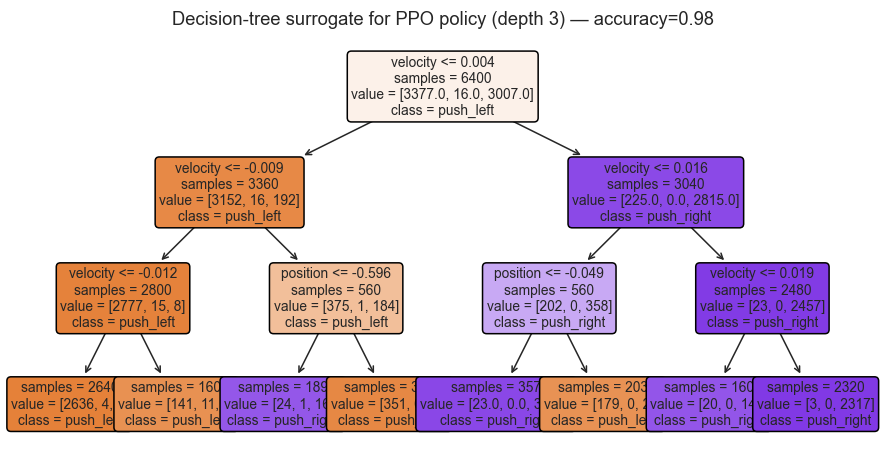


Feature importances: {'position': 0.115, 'velocity': 0.885}


In [10]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Sample the policy on a uniform grid across the state space.
positions  = np.linspace(-1.2, 0.6, 80)
velocities = np.linspace(-0.07, 0.07, 80)
grid = np.array([[p, v] for p in positions for v in velocities])

actions, _ = ppo_pred.predict(grid, deterministic=True)
actions = np.asarray(actions).ravel()
clf = DecisionTreeClassifier(max_depth=3, random_state=SEED).fit(grid, actions)

fig, ax = plt.subplots(figsize=(10, 5))
plot_tree(
    clf, ax=ax, filled=True, rounded=True,
    feature_names=["position", "velocity"],
    class_names=["push_left", "no_op", "push_right"],
    impurity=False, fontsize=9,
)
ax.set_title(f"Decision-tree surrogate for PPO policy (depth 3) — accuracy={clf.score(grid, actions):.2f}")
plt.savefig(os.path.join(FIGS_DIR, "policy_decision_tree_ppo.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\nFeature importances:", dict(zip(["position", "velocity"], clf.feature_importances_.round(3))))

## 10. Conclusions

**All three algorithms solve Scenario 1 on the default sparse reward**, ranked by mean steps to goal:

| Rank | Algorithm | Mean steps | Success rate | Train time |
|---|---|---|---|---|
| 1 | **DQN** | ≈ 99.7 | 100 % | ~3 min |
| 2 | **PPO** | ≈ 116.6 | 100 % | ~2 min (16 envs) |
| 3 | **A2C** | ≈ 131.1 | 100 % | ~2 min (16 envs) |

**DQN wins** on mean steps. As an off-policy method with a replay buffer, every observation of the agent reaching the flag is reused many times — extremely sample-efficient on a sparse-reward problem, and the result is a tighter policy that solves the task in ~100 steps versus PPO's ~117 and A2C's ~131.

**PPO is the strongest actor-critic** of the two on-policy methods we tested. The clipped policy gradient and GAE advantage estimator give it both stability and reasonable sample efficiency. A2C — the textbook implementation of §13.5 — also reaches 100 % success but is noisier per update (no clipping) and converges to a slightly slower policy.

**The reward-shaping comparison ran the *opposite* way to the textbook intuition.** With observation/reward normalisation already on (`VecNormalize`), the on-policy actor-critics solve the unshaped problem cleanly, but adding velocity+height shaping on top *broke* them — reward magnitudes get rescaled by `VecNormalize`'s running std, so the shaping bonus dominates the per-step `-1` and the agent collapses to a "swing forever in the valley" local optimum without escaping. This is itself a useful lesson: input/output normalisation can do most of what hand-crafted reward shaping aims to achieve, and stacking them can hurt.

**Policy character.** The decision-tree surrogate for the headline PPO policy (depth 3) shows that **velocity sign carries most of the information**: the policy is essentially "push with the velocity" — push right when moving right, push left when moving left, with position only mattering near the boundaries. The phase portrait confirms this: trajectories spiral outward in the (position, velocity) plane until they have enough kinetic energy to climb the right slope.

**What we'd try next.**

- **Multiple seeds** for each (algo, reward_mode) pair, so the comparison has error bars rather than single-point estimates.
- **Tabular Q-learning** on a discretised state — pedagogically clean side-by-side with DQN, and the Q-table itself is a one-look policy summary.
- **Disable VecNormalize and re-test shaping** to see whether a lighter shaping (without normalisation) recovers the textbook story.

**Output files** for the cross-scenario teammate (under `results/scenario_1/`):

- `metrics.json` — machine-readable per-agent stats.
- `figs/training_curves.png`, `figs/policy_heatmap_*.png`, `figs/phase_portrait_ppo.png`, `figs/policy_decision_tree_ppo.png`, `figs/metrics_table.png` — slide-ready figures.
- `models/*.zip` + `models/*.vecnormalize.pkl` — trained SB3 models with their normalisation stats.

Wrote /Users/matthewmaingot/RL_Group_Project/MountainCar-RL/results/scenario_1/metrics.json


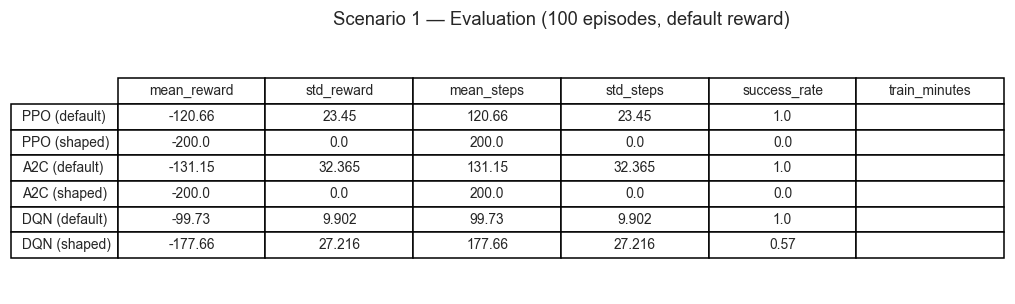

In [11]:
# Persist machine-readable metrics + a slide-ready table image.
json_path = save_metrics(RESULTS_DIR, scenario=SCENARIO, results=results_for_json)
print(f"Wrote {json_path}")

table_for_slide = results_df.reset_index().set_index(
    results_df.reset_index()["algo"] + " (" + results_df.reset_index()["reward_mode"] + ")"
).drop(columns=["algo", "reward_mode"])
save_metrics_table_png(
    table_for_slide,
    save_path=os.path.join(FIGS_DIR, "metrics_table.png"),
    title="Scenario 1 — Evaluation (100 episodes, default reward)",
)